<h1>Modeli ansambala stabala odlučivanja</h1>
<h2>Uvođenje potrebnih paketa</h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import tree
from sklearn import ensemble
import xgboost
np.random.seed(7)

In [2]:
import joblib

<h2>Učitavanje pretprocesiranih podataka</h2>

In [3]:
data = pd.read_csv("preprocessed_data.csv",index_col=0)

In [4]:
data.head()

,Education Level,Finance,Science,Business,Computer Science,Arts,Psychology,Commerce,Engineering,Counseling,...,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage,Recommended Career
0,2,1,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,67,Business Analyst
1,1,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,67,Software Engineer
2,3,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,90,Financial Analyst
3,2,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,75,Clerk
4,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,83,Sales Assistant


In [5]:
target = 'Recommended Career'

<h2>Izdvajanje atributa</h2>

In [6]:
x = data.drop(labels = [target], axis=1)
x

,Education Level,Finance,Science,Business,Computer Science,Arts,Psychology,Commerce,Engineering,Counseling,...,Python,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage
0,2,1,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,67
1,1,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,67
2,3,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,90
3,2,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,75
4,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,0,0,0,0,0,0,1,0,0,...,1,0,1,0,0,0,0,0,0,90
4996,3,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,92
4997,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,63
4998,4,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,83


<h2>Izdvajanje i label enkodovanje ciljne promenljive</h2>

In [7]:
target_names = data[target].unique()

y = data[target]

label_encoder = preprocessing.LabelEncoder()
y_encoded = label_encoder.fit_transform( data[target] )

y_encoded

array([ 0, 11,  3, ...,  3, 11,  1], shape=(5000,))

<h2>Podela podataka na skupove za testiranje, validaciju i testiranje i standardizacija</h2>
Vrši se podela podataka na skup nad kojim će model trenirati(trening skup), skup nad kojim će se vršiti evaluacija modela u cilju izbora optimalnih parametara(validacioni skup) i skup koji će se koristiti za evaluaciju modela i davanje konačne ocene tog modela(test skup). Podela se vrši pomoću funkcije train_test_split pri čemu uzimamo trećinu podataka za skup za testiranje, a od preostale dve trećine 80% za treniranje, a 20% za validaciju. Takođe vodimo računa o stratifikaciji da bi udeo klasa ciljne promenljive u svakom skupu bio procentualno jednak. Parametar random_state postavljamo na vrednost 7 kako bi se modeli mogli reprodukovati.

In [8]:
x_trainval, x_test, y_trainval, y_test = model_selection.train_test_split(x, y_encoded, test_size=0.33, stratify=y_encoded, random_state = 7)

In [9]:
x_train, x_val, y_train, y_val = model_selection.train_test_split(x_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state = 7)
scalerTrain = preprocessing.StandardScaler()
scalerTrain.fit(x_train)
x_train = scalerTrain.transform(x_train)
x_val = scalerTrain.transform(x_val)

In [10]:
scalerTrainval = preprocessing.StandardScaler()
scalerTrainval.fit(x_trainval)
x_trainval = scalerTrainval.transform(x_trainval)
x_test = scalerTrainval.transform(x_test)

<h2>Izbor optimalnih hiperparametara za RandomForest model</h2>

In [11]:
def train_and_evaluate(model, x_train, y_train, x_val, y_val):
    model.fit(x_train, y_train)

    return model.score(x_val, y_val)

In [12]:
number_of_estimators = np.arange(10, 110, 10)
number_of_estimators

array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100])

In [13]:
max_depths = np.arange(5, 55, 5)
max_depths

array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])

In [14]:
optimal_number_of_estimators = number_of_estimators[0]
optimal_depth = max_depths[0]
optimal_accuracy = 0

for num in number_of_estimators:
    for depth in max_depths:
        model = ensemble.RandomForestClassifier(num, max_depth=depth, random_state=7)
        score = train_and_evaluate(model, x_train, y_train, x_val, y_val)
        
        if score > optimal_accuracy:
            optimal_accuracy = score
            optimal_number_of_estimators = num
            optimal_depth = depth

print(optimal_number_of_estimators, optimal_depth, optimal_accuracy)

60 10 0.1044776119402985


In [15]:
number_of_estimators = np.arange(optimal_number_of_estimators-9, optimal_number_of_estimators+11, 2)
number_of_estimators

max_depths = np.arange(optimal_depth-4, optimal_depth+6, 1)
max_depths

for num in number_of_estimators:
    for depth in max_depths:
        model = ensemble.RandomForestClassifier(num, max_depth=depth, random_state=7)
        score = train_and_evaluate(model, x_train, y_train, x_val, y_val)
        
        if score > optimal_accuracy:
            optimal_accuracy = score
            optimal_number_of_estimators = num
            optimal_depth = depth

print(optimal_number_of_estimators, optimal_depth, optimal_accuracy)

53 11 0.10746268656716418


<h2>Pravljenje i treniranje RandomForest modela</h2>

In [16]:
model = ensemble.RandomForestClassifier(optimal_number_of_estimators, max_depth=optimal_depth, random_state=7)

In [17]:
model.fit(x_trainval, y_trainval)

,n_estimators,np.int64(53)
,criterion,'gini'
,max_depth,np.int64(11)
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<h2>Evaluacija RandomForest modela</h2>

In [18]:
y_test_predicted = model.predict(x_test)
y_test_predicted

array([5, 1, 4, ..., 0, 3, 6], shape=(1650,))

In [19]:
y_test_predicted_strings = label_encoder.inverse_transform(y_test_predicted)
y_test_predicted_strings

array(['ML Engineer', 'Clerk', 'Junior Accountant', ...,
       'Business Analyst', 'Financial Analyst', 'Marketing Executive'],
      shape=(1650,), dtype=object)

In [20]:
model.score(x_trainval, y_trainval)

0.9370149253731344

In [21]:
model.score(x_test, y_test)

0.07090909090909091

Na osnovu visoke tačnosti RandomForest modela na trening skupu, a izuzetno niske tačnosti na test skupu možemo zaključiti da se model preprilagodio. Kao i kod prošlog modela vidimo da su rezultati slični kao kod prethodnog modela što može da ukazuje kvalitet skupa podataka

In [22]:
metrics.confusion_matrix(y_test, y_test_predicted)

array([[ 3, 14,  5, 10,  9,  8, 14, 16, 19, 14, 11,  7],
       [ 8, 10,  7, 17, 12, 10, 15, 12, 13,  9, 14, 16],
       [ 7, 27, 13,  7, 23, 10,  7,  6,  7,  7, 13,  9],
       [10, 16, 18,  6, 12, 10, 15, 10,  4,  8, 15, 12],
       [ 9, 18, 15, 15,  9,  7, 12,  5, 12,  9, 14, 11],
       [ 9, 16, 14,  7, 11,  9, 14, 10,  8, 11, 14, 19],
       [ 8, 19,  6,  8, 10, 16, 12, 10, 12, 10, 12, 20],
       [12, 15,  8,  4, 13, 16, 21,  9,  5, 11, 11,  9],
       [11, 20, 10,  9, 14,  9,  8,  9, 16,  8, 12, 12],
       [ 9, 11, 21,  9,  6,  9, 14,  8, 12,  8, 13, 16],
       [13,  9, 14,  7,  6,  8, 18, 12, 20, 10, 12,  9],
       [ 6, 11, 14,  2, 10, 12, 16, 12, 15, 14, 16, 10]])

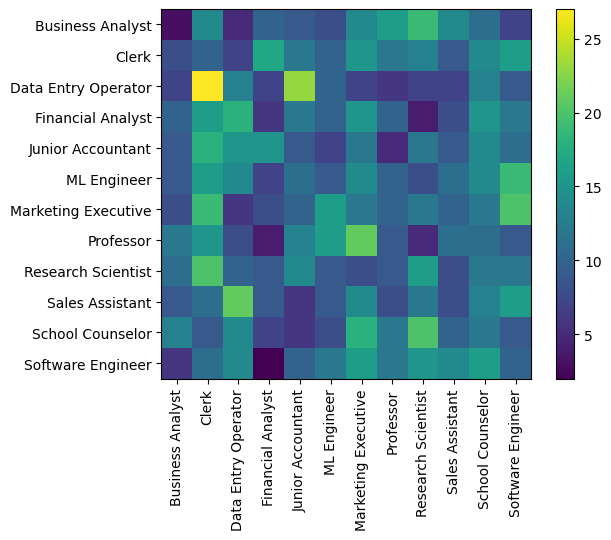

In [23]:
classes_for_display = label_encoder.inverse_transform(range(0, 12))
plt.imshow(metrics.confusion_matrix(y_test, y_test_predicted))
plt.xticks(range(0,  12), labels = classes_for_display, rotation='vertical')
plt.yticks(range(0,  12), labels = classes_for_display)
plt.colorbar()
plt.show()

Isto se može zaključiti i iz matrice konfuzije

In [24]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.03      0.02      0.03       130
           1       0.05      0.07      0.06       143
           2       0.09      0.10      0.09       136
           3       0.06      0.04      0.05       136
           4       0.07      0.07      0.07       136
           5       0.07      0.06      0.07       142
           6       0.07      0.08      0.08       143
           7       0.08      0.07      0.07       134
           8       0.11      0.12      0.11       138
           9       0.07      0.06      0.06       136
          10       0.08      0.09      0.08       138
          11       0.07      0.07      0.07       138

    accuracy                           0.07      1650
   macro avg       0.07      0.07      0.07      1650
weighted avg       0.07      0.07      0.07      1650



<h2>Čuvanje modela</h2>

In [25]:
joblib.dump(label_encoder, 'Models/RandomForest/label_encoder.pkl')

['Models/RandomForest/label_encoder.pkl']

In [26]:
joblib.dump(scalerTrain, 'Models/RandomForest/standard_scaler_train.pkl')

['Models/RandomForest/standard_scaler_train.pkl']

In [27]:
joblib.dump(scalerTrainval, 'Models/RandomForest/standard_scaler_trainval.pkl')

['Models/RandomForest/standard_scaler_trainval.pkl']

In [28]:
joblib.dump(model, 'Models/RandomForest/model.pkl')

['Models/RandomForest/model.pkl']

<h2>Izbor optimalnih hiperparametara za AdaBoost model sa stablima odlučivanja</h2>

In [29]:
number_of_estimators = np.arange(50, 150, 10)

max_depths = np.arange(5, 25, 2)

optimal_number_of_estimators = number_of_estimators[0]
optimal_depth = max_depths[0]
optimal_accuracy = 0

for num in number_of_estimators:
    for depth in max_depths:
        model = ensemble.AdaBoostClassifier(estimator=tree.DecisionTreeClassifier(max_depth=depth), n_estimators=num, random_state=7)
        score = train_and_evaluate(model, x_train, y_train, x_val, y_val)
        
        if score > optimal_accuracy:
            optimal_accuracy = score
            optimal_number_of_estimators = num
            optimal_depth = depth

print(optimal_number_of_estimators, optimal_depth, optimal_accuracy)

80 11 0.11194029850746269


<h2>Pravljenje i treniranje AdaBoost modela</h2>

In [30]:
model = ensemble.AdaBoostClassifier(estimator=tree.DecisionTreeClassifier(max_depth=optimal_depth), n_estimators=optimal_number_of_estimators, random_state=7)

In [31]:
model.fit(x_trainval, y_trainval)

,estimator,DecisionTreeC...=np.int64(11))
,n_estimators,np.int64(80)
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,7
,criterion,'gini'
,splitter,'best'
,max_depth,np.int64(11)
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


<h2>Evaluacija AdaBoost modela</h2>

In [32]:
y_test_predicted = model.predict(x_test)
y_test_predicted

array([5, 1, 6, ..., 0, 0, 7], shape=(1650,))

In [33]:
model.score(x_train, y_train)

0.9985074626865672

In [34]:
model.score(x_test, y_test)

0.07272727272727272

Kao i kod prethodnog modela možemo zaključiti da se model preprilagodio i da je model veoma loš u predviđanju ciljne promenljive

In [35]:
metrics.confusion_matrix(y_test, y_test_predicted)

array([[ 6, 10, 10,  6, 12, 12,  9, 12, 16,  8, 18, 11],
       [11, 11,  5, 16, 10, 13, 15, 15, 11, 10, 12, 14],
       [ 7, 26,  5, 11, 14, 15, 12,  9,  9, 11,  8,  9],
       [12, 16, 16,  5,  9, 10, 12,  9,  8,  9, 13, 17],
       [ 2, 14, 10,  9, 11, 15, 11, 22, 14,  9,  8, 11],
       [10, 18,  8, 15,  8, 18,  9,  8,  7,  8, 13, 20],
       [11, 21, 13,  6,  8, 11, 11, 11, 16, 13,  7, 15],
       [12, 17, 11,  4,  9, 11,  7, 13,  9, 14, 11, 16],
       [ 8, 18,  9, 12, 13, 11,  9, 15, 10, 10, 12, 11],
       [14, 12, 12,  8,  8, 13,  9, 12, 13,  6, 13, 16],
       [10, 17, 13,  9,  8, 11,  9, 12, 11, 11, 10, 17],
       [ 7, 17, 11, 11,  6, 16,  8, 11, 16,  9, 12, 14]])

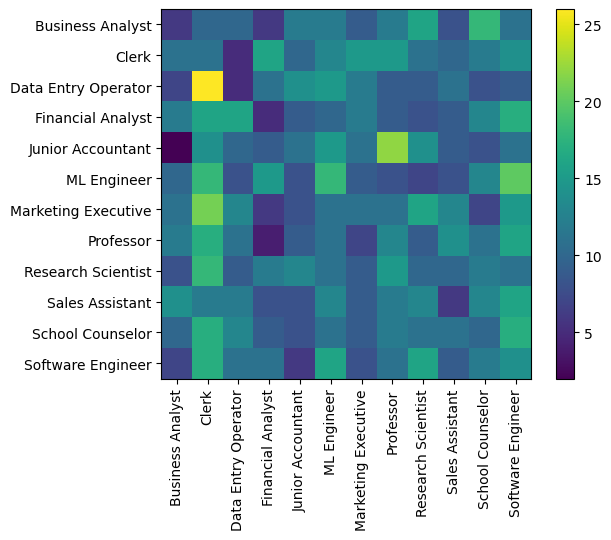

In [36]:
classes_for_display = label_encoder.inverse_transform(range(0, 12))
plt.imshow(metrics.confusion_matrix(y_test, y_test_predicted))
plt.xticks(range(0,  12), labels = classes_for_display, rotation='vertical')
plt.yticks(range(0,  12), labels = classes_for_display)
plt.colorbar()
plt.show()

In [37]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.05      0.05      0.05       130
           1       0.06      0.08      0.06       143
           2       0.04      0.04      0.04       136
           3       0.04      0.04      0.04       136
           4       0.09      0.08      0.09       136
           5       0.12      0.13      0.12       142
           6       0.09      0.08      0.08       143
           7       0.09      0.10      0.09       134
           8       0.07      0.07      0.07       138
           9       0.05      0.04      0.05       136
          10       0.07      0.07      0.07       138
          11       0.08      0.10      0.09       138

    accuracy                           0.07      1650
   macro avg       0.07      0.07      0.07      1650
weighted avg       0.07      0.07      0.07      1650



<h2>Čuvanje modela</h2>

In [38]:
joblib.dump(label_encoder, 'Models/AdaBoost/label_encoder.pkl')

['Models/AdaBoost/label_encoder.pkl']

In [39]:
joblib.dump(scalerTrain, 'Models/AdaBoost/standard_scaler_train.pkl')

['Models/AdaBoost/standard_scaler_train.pkl']

In [40]:
joblib.dump(scalerTrainval, 'Models/AdaBoost/standard_scaler_trainval.pkl')

['Models/AdaBoost/standard_scaler_trainval.pkl']

In [41]:
joblib.dump(model, 'Models/AdaBoost/model.pkl')

['Models/AdaBoost/model.pkl']

<h2>Izbor optimalnih hiperparametara za XGBoost model</h2>

In [42]:
number_of_estimators = np.arange(50, 150, 10)
number_of_estimators

max_depths = np.arange(5, 25, 2)
max_depths

optimal_number_of_estimators = number_of_estimators[0]
optimal_depth = max_depths[0]
optimal_accuracy = 0

for num in number_of_estimators:
    for depth in max_depths:
        model = xgboost.XGBClassifier(n_estimators=num, max_depth=depth, random_state=7)
        score = train_and_evaluate(model, x_train, y_train, x_val, y_val)
        
        if score > optimal_accuracy:
            optimal_accuracy = score
            optimal_number_of_estimators = num
            optimal_depth = depth

print(optimal_number_of_estimators, optimal_depth, optimal_accuracy)

90 9 0.1044776119402985


<h2>Pravljenje i treniranje XGBoost modela</h2>

In [43]:
model = xgboost.XGBClassifier(n_estimators=optimal_number_of_estimators, max_depth=optimal_depth, random_state=7)

In [44]:
model.fit(x_trainval, y_trainval)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


<h2>Evaluacija XGBoost modela</h2>

In [45]:
y_test_predicted = model.predict(x_test)
y_test_predicted

array([ 5,  1, 11, ...,  2,  3,  7], shape=(1650,))

In [46]:
model.score(x_train, y_train)

0.18358208955223881

In [47]:
model.score(x_test, y_test)

0.06909090909090909

Ni XGBoost nije bolji od prethodnih modela

In [48]:
metrics.confusion_matrix(y_test, y_test_predicted)

array([[ 7, 14,  5,  9, 14, 10, 13, 13, 15, 10, 10, 10],
       [ 8, 15,  8, 14, 10,  9,  9, 15, 16, 10, 14, 15],
       [10, 21,  9,  8, 10, 12, 11,  7,  9, 10, 21,  8],
       [12, 14, 11, 11,  9, 18, 13,  6,  5, 10, 19,  8],
       [ 7, 12, 22,  9, 10,  8, 16, 11,  9, 12,  8, 12],
       [10, 12, 11, 10,  9, 14, 14, 12, 10,  9, 14, 17],
       [ 9, 19, 19,  6, 15,  5, 10,  9, 14, 13, 11, 13],
       [13, 16,  7,  8,  6, 17, 15,  5,  9, 15, 11, 12],
       [ 7, 19, 10, 21, 10, 21,  7,  8,  7, 12,  7,  9],
       [11, 13, 20,  8,  8,  9, 16,  9, 13,  6, 10, 13],
       [ 9, 18, 13,  9,  8,  6, 13, 14, 12, 13, 11, 12],
       [11, 16, 11, 12, 13, 18, 14, 11,  8,  4, 11,  9]])

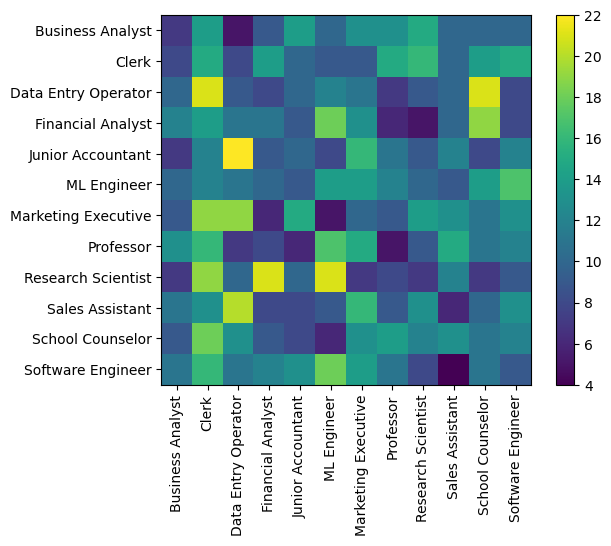

In [49]:
classes_for_display = label_encoder.inverse_transform(range(0, 12))
plt.imshow(metrics.confusion_matrix(y_test, y_test_predicted))
plt.xticks(range(0,  12), labels = classes_for_display, rotation='vertical')
plt.yticks(range(0,  12), labels = classes_for_display)
plt.colorbar()
plt.show()

In [50]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.06      0.05      0.06       130
           1       0.08      0.10      0.09       143
           2       0.06      0.07      0.06       136
           3       0.09      0.08      0.08       136
           4       0.08      0.07      0.08       136
           5       0.10      0.10      0.10       142
           6       0.07      0.07      0.07       143
           7       0.04      0.04      0.04       134
           8       0.06      0.05      0.05       138
           9       0.05      0.04      0.05       136
          10       0.07      0.08      0.08       138
          11       0.07      0.07      0.07       138

    accuracy                           0.07      1650
   macro avg       0.07      0.07      0.07      1650
weighted avg       0.07      0.07      0.07      1650



<h2>Čuvanje modela</h2>

In [51]:
joblib.dump(label_encoder, 'Models/XGBoost/label_encoder.pkl')

['Models/XGBoost/label_encoder.pkl']

In [52]:
joblib.dump(scalerTrain, 'Models/XGBoost/standard_scaler_train.pkl')

['Models/XGBoost/standard_scaler_train.pkl']

In [53]:
joblib.dump(scalerTrainval, 'Models/XGBoost/standard_scaler_trainval.pkl')

['Models/XGBoost/standard_scaler_trainval.pkl']

In [54]:
joblib.dump(model, 'Models/XGBoost/model.pkl')

['Models/XGBoost/model.pkl']